<a href="https://colab.research.google.com/github/RickV777/ENGAGEMENT_YT/blob/main/YouTube_TFT_Objetivo2_PruebasHipotesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS DE LOS FACTORES DETERMINANTES DEL ENGAGEMENT EN YOUTUBE
## Notebook 2 — Pruebas de Hipotesis (Estadistica Inferencial)
**Universidad de Guayaquil — Facultad de Ciencias Matematicas y Fisicas — Carrera de Software**

---

## OBJETIVO 2
> Aplicar pruebas de hipotesis (t-test, ANOVA, Kruskal-Wallis, chi-cuadrado) para determinar
> si existen diferencias estadisticamente significativas en el engagement entre categorias de
> contenido, horarios de publicacion y rangos de duracion.

### Hipotesis general
- **H0**: No existen diferencias estadisticamente significativas en el engagement entre los grupos analizados.
- **H1**: Existen diferencias estadisticamente significativas en el engagement entre al menos dos grupos.

### Nivel de significancia
- alpha = 0.05 (5%)

### Pruebas a aplicar
| Prueba | Variable de agrupacion | Tipo |
|---|---|---|
| Shapiro-Wilk / K-S | — | Normalidad |
| Levene | Todos los grupos | Homocedasticidad |
| t-test / Mann-Whitney U | Pais (US vs MX) | 2 grupos |
| ANOVA / Kruskal-Wallis | Categoria de contenido | Multiples grupos |
| ANOVA / Kruskal-Wallis | Franja horaria | Multiples grupos |
| ANOVA / Kruskal-Wallis | Rango de tags | Multiples grupos |
| Chi-cuadrado | Comments/Ratings disabled | Categoricas |
| Post-hoc Dunn | Pares significativos | Comparacion multiple |


---
## SECCION 1 — Instalacion e Importacion de Librerias

In [2]:
!pip install scikit_posthocs pingouin --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.7 MB/s eta 0:00:00


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Estadistica
from scipy import stats
from scipy.stats import (shapiro, kstest, levene, ttest_ind,
                          mannwhitneyu, f_oneway, kruskal, chi2_contingency,
                          normaltest)
import scikit_posthocs as sp
import pingouin as pg

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

ALPHA = 0.05
OUTPUT_DIR = '/content/figuras_obj2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Librerias cargadas correctamente')
print(f'Nivel de significancia: alpha = {ALPHA}')

Librerias cargadas correctamente
Nivel de significancia: alpha = 0.05


---
## SECCION 2 — Carga del Dataset Procesado

In [5]:
# Opcion A: cargar desde /content/ (si el NB1 se ejecuto en la misma sesion)
# Opcion B: cargar desde Google Drive

# --- OPCION A (por defecto) ---
#CSV_PATH = '/content/youtube_dataset_procesado.csv'

# --- OPCION B: descomentar si cargamos desde Drive ---
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/youtube_dataset_procesado.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['publishedAt', 'trending_date'])

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Paises: {df["country"].value_counts().to_dict()}')
print(f'Periodo: {df["trending_date"].min().date()} -> {df["trending_date"].max().date()}')
display(df.head(3))

Mounted at /content/drive
Dataset cargado: 528,663 filas x 26 columnas
Paises: {'US': 264439, 'MX': 264224}
Periodo: 2020-08-12 -> 2024-04-14


,video_id,country,publishedAt,trending_date,publish_hour,publish_dayofweek,publish_dayname,publish_month,publish_year,franja_horaria,dias_hasta_trending,category_name,title_length,num_tags,rango_tags,rango_titulo,comments_disabled,ratings_disabled,view_count,likes,comment_count,log_views,log_likes,log_comments,engagement_rate,log_engagement
0,3C66w5Z0ixs,US,2020-08-11 19:20:14+00:00,2020-08-12 00:00:00+00:00,19,1,Martes,8,2020,Noche (18-24h),0.1943,People & Blogs,34,15,11-20,Medio (31-60),False,False,1514614,156908,35313,14.2307,11.9634,10.4720,0.1269,0.1195
1,M9Pmf9AB4Mo,US,2020-08-11 17:00:10+00:00,2020-08-12 00:00:00+00:00,17,1,Martes,8,2020,Tarde (12-18h),0.2916,Gaming,60,25,21-30,Medio (31-60),False,False,2381688,146739,16549,14.6833,11.8964,9.7141,0.0686,0.0663
2,J78aPJ3VyNs,US,2020-08-11 16:34:06+00:00,2020-08-12 00:00:00+00:00,16,1,Martes,8,2020,Tarde (12-18h),0.3097,Entertainment,53,30,21-30,Medio (31-60),False,False,2038853,353787,40221,14.5279,12.7765,10.6022,0.1932,0.1767


In [6]:
# Verificar que existan las columnas necesarias
cols_requeridas = ['engagement_rate', 'log_engagement', 'category_name',
                   'franja_horaria', 'country', 'num_tags', 'rango_tags',
                   'comments_disabled', 'ratings_disabled']

faltantes = [c for c in cols_requeridas if c not in df.columns]
if faltantes:
    print(f'ADVERTENCIA - Columnas faltantes: {faltantes}')
else:
    print('Todas las columnas requeridas estan presentes')

print(f'\nEstadisticas de engagement_rate:')
print(df['engagement_rate'].describe())

Todas las columnas requeridas estan presentes

Estadisticas de engagement_rate:
count   528663.0000
mean         0.0613
std          0.0450
min          0.0000
25%          0.0288
50%          0.0531
75%          0.0813
max          0.5863
Name: engagement_rate, dtype: float64


---
## SECCION 3 — Pruebas de Normalidad

> Antes de elegir entre pruebas parametricas (ANOVA, t-test) o no parametricas
> (Kruskal-Wallis, Mann-Whitney), es obligatorio verificar si el engagement sigue
> una distribucion normal.

- **Shapiro-Wilk**: recomendada para n < 5000
- **Kolmogorov-Smirnov**: para n grande
- **D'Agostino-Pearson**: basada en asimetria y curtosis


In [7]:
# Con 528k registros Shapiro-Wilk es muy lento -> usamos muestra de 5000
np.random.seed(42)
muestra = df['engagement_rate'].dropna().sample(5000)

# Shapiro-Wilk (muestra)
stat_sw, p_sw = shapiro(muestra)

# Kolmogorov-Smirnov vs normal
stat_ks, p_ks = kstest(
    df['engagement_rate'].dropna(),
    'norm',
    args=(df['engagement_rate'].mean(), df['engagement_rate'].std())
)

# D'Agostino-Pearson
stat_dp, p_dp = normaltest(df['engagement_rate'].dropna())

print('=' * 55)
print('  PRUEBAS DE NORMALIDAD — engagement_rate')
print('=' * 55)
print(f'  Shapiro-Wilk  (n=5000) : W={stat_sw:.4f}  p={p_sw:.4e}')
print(f'  Kolmogorov-Smirnov     : D={stat_ks:.4f}  p={p_ks:.4e}')
print(f'  D Agostino-Pearson     : K={stat_dp:.4f}  p={p_dp:.4e}')
print('=' * 55)

normalidad = all(p > ALPHA for p in [p_sw, p_ks, p_dp])
if normalidad:
    print('CONCLUSION: No se rechaza H0 -> distribucion NORMAL')
    print('Se usaran pruebas PARAMETRICAS (t-test, ANOVA)')
else:
    print('CONCLUSION: Se rechaza H0 -> distribucion NO NORMAL')
    print('Se usaran pruebas NO PARAMETRICAS (Mann-Whitney, Kruskal-Wallis)')

  PRUEBAS DE NORMALIDAD — engagement_rate
  Shapiro-Wilk  (n=5000) : W=0.8725  p=2.1676e-53
  Kolmogorov-Smirnov     : D=0.0910  p=0.0000e+00
  D Agostino-Pearson     : K=187689.4437  p=0.0000e+00
CONCLUSION: Se rechaza H0 -> distribucion NO NORMAL
Se usaran pruebas NO PARAMETRICAS (Mann-Whitney, Kruskal-Wallis)


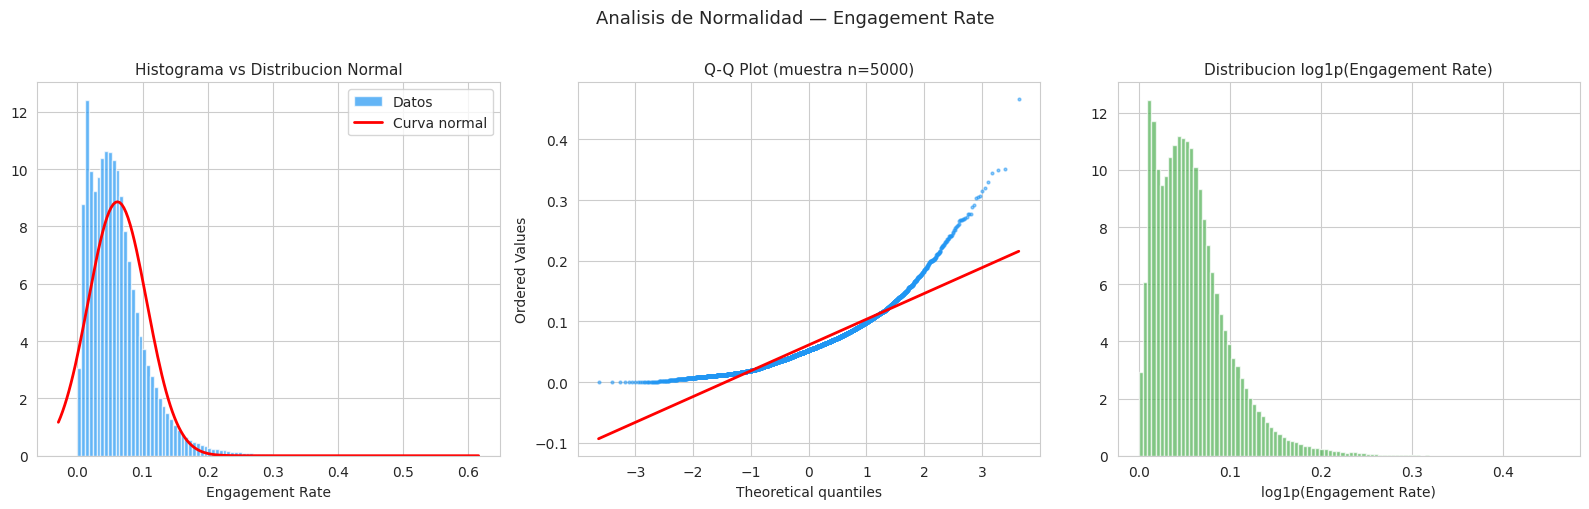

Figura guardada: fig_01_normalidad.png


In [8]:
# Visualizacion de normalidad
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma con curva normal
data_plot = df['engagement_rate'].dropna()
axes[0].hist(data_plot, bins=100, density=True, color='#2196F3', alpha=0.7, label='Datos')
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
axes[0].plot(x, stats.norm.pdf(x, data_plot.mean(), data_plot.std()),
             'r-', lw=2, label='Curva normal')
axes[0].set_title('Histograma vs Distribucion Normal', fontsize=11)
axes[0].set_xlabel('Engagement Rate')
axes[0].legend()

# Q-Q Plot
stats.probplot(muestra, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (muestra n=5000)', fontsize=11)
axes[1].get_lines()[0].set(color='#2196F3', markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color='red', lw=2)

# Histograma log_engagement
axes[2].hist(df['log_engagement'].dropna(), bins=100,
             density=True, color='#4CAF50', alpha=0.7)
axes[2].set_title('Distribucion log1p(Engagement Rate)', fontsize=11)
axes[2].set_xlabel('log1p(Engagement Rate)')

fig.suptitle('Analisis de Normalidad — Engagement Rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_01_normalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_01_normalidad.png')

---
## SECCION 4 — Prueba de Homocedasticidad (Levene)

> Verifica si la varianza del engagement es igual entre grupos.
> Si no hay homocedasticidad se ajusta la interpretacion de ANOVA.


In [9]:
# Homocedasticidad por pais
grupos_pais = [g['engagement_rate'].dropna().values
               for _, g in df.groupby('country')]
stat_lev_pais, p_lev_pais = levene(*grupos_pais)

# Homocedasticidad por categoria
grupos_cat = [g['engagement_rate'].dropna().values
              for _, g in df.groupby('category_name')
              if len(g) > 30]
stat_lev_cat, p_lev_cat = levene(*grupos_cat)

# Homocedasticidad por franja horaria
grupos_franja = [g['engagement_rate'].dropna().values
                 for _, g in df.groupby('franja_horaria')]
stat_lev_franja, p_lev_franja = levene(*grupos_franja)

print('=' * 58)
print('  PRUEBA DE LEVENE — Homocedasticidad')
print('=' * 58)
print(f'  Por pais          : W={stat_lev_pais:.4f}   p={p_lev_pais:.4e}  {"HETEROCEDASTICO" if p_lev_pais < ALPHA else "Homocedástico"}')
print(f'  Por categoria     : W={stat_lev_cat:.4f}   p={p_lev_cat:.4e}  {"HETEROCEDASTICO" if p_lev_cat < ALPHA else "Homocedástico"}')
print(f'  Por franja horaria: W={stat_lev_franja:.4f}   p={p_lev_franja:.4e}  {"HETEROCEDASTICO" if p_lev_franja < ALPHA else "Homocedástico"}')
print('=' * 58)
print('CONCLUSION: Se confirmara uso de pruebas no parametricas')

  PRUEBA DE LEVENE — Homocedasticidad
  Por pais          : W=9537.7334   p=0.0000e+00  HETEROCEDASTICO
  Por categoria     : W=3015.9946   p=0.0000e+00  HETEROCEDASTICO
  Por franja horaria: W=320.4556   p=6.6811e-208  HETEROCEDASTICO
CONCLUSION: Se confirmara uso de pruebas no parametricas


---
## SECCION 5 — Hipotesis 1: Diferencias entre Paises (US vs MX)

- **H0**: No existe diferencia significativa en el engagement entre US y MX
- **H1**: Existe diferencia significativa en el engagement entre US y MX
- **Prueba**: Mann-Whitney U (no parametrica, 2 grupos independientes)


In [10]:
us_eng = df[df['country'] == 'US']['engagement_rate'].dropna()
mx_eng = df[df['country'] == 'MX']['engagement_rate'].dropna()

stat_mw, p_mw = mannwhitneyu(us_eng, mx_eng, alternative='two-sided')

# Calculo del effect size r = Z / sqrt(N)
n_total = len(us_eng) + len(mx_eng)
z_score = stats.norm.ppf(p_mw / 2)
r_effect = abs(z_score) / np.sqrt(n_total)

print('=' * 58)
print('  MANN-WHITNEY U — US vs MX')
print('=' * 58)
print(f'  n US              : {len(us_eng):,}')
print(f'  n MX              : {len(mx_eng):,}')
print(f'  Mediana US        : {us_eng.median():.4f}')
print(f'  Mediana MX        : {mx_eng.median():.4f}')
print(f'  Estadistico U     : {stat_mw:.2f}')
print(f'  p-valor           : {p_mw:.4e}')
print(f'  Effect size r     : {r_effect:.4f}')
print('=' * 58)
if p_mw < ALPHA:
    print(f'RESULTADO: Se RECHAZA H0 (p={p_mw:.4e} < {ALPHA})')
    print('Existe diferencia significativa en engagement entre US y MX')
else:
    print(f'RESULTADO: No se rechaza H0 (p={p_mw:.4e} >= {ALPHA})')

  MANN-WHITNEY U — US vs MX
  n US              : 264,439
  n MX              : 264,224
  Mediana US        : 0.0498
  Mediana MX        : 0.0573
  Estadistico U     : 31269255942.00
  p-valor           : 0.0000e+00
  Effect size r     : inf
RESULTADO: Se RECHAZA H0 (p=0.0000e+00 < 0.05)
Existe diferencia significativa en engagement entre US y MX


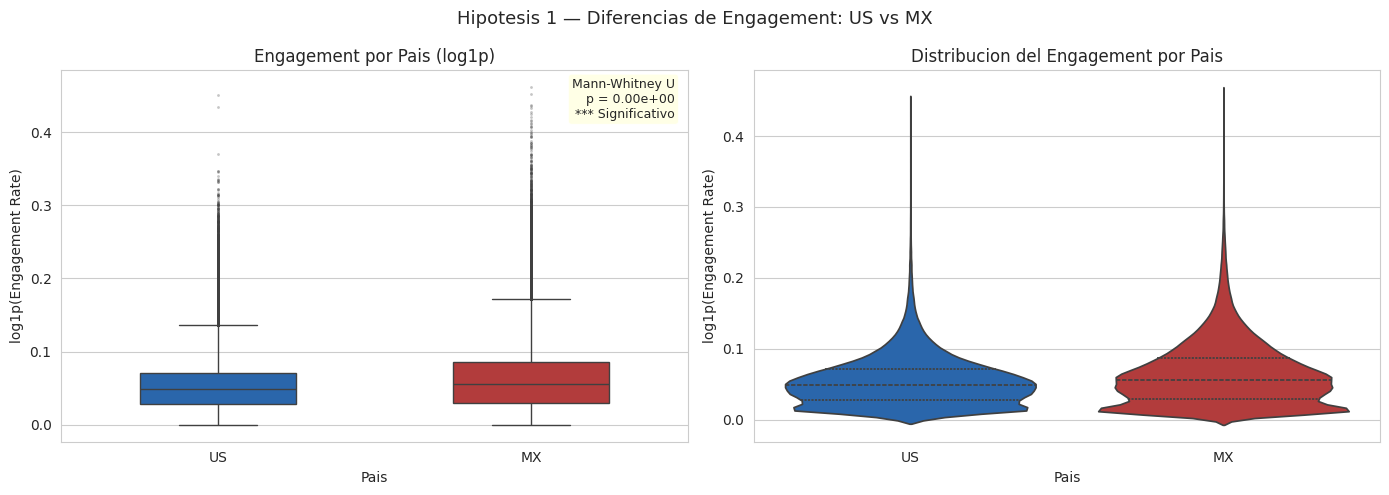

Figura guardada: fig_02_us_vs_mx.png


In [11]:
# Visualizacion US vs MX
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
colores_pais = {'US': '#1565C0', 'MX': '#C62828'}
sns.boxplot(data=df, x='country', y='log_engagement',
            palette=colores_pais, width=0.5,
            flierprops=dict(marker='o', markersize=1, alpha=0.3),
            ax=axes[0])
axes[0].set_title('Engagement por Pais (log1p)', fontsize=12)
axes[0].set_xlabel('Pais')
axes[0].set_ylabel('log1p(Engagement Rate)')
sig_text = f'Mann-Whitney U\np = {p_mw:.2e}\n{"*** Significativo" if p_mw < ALPHA else "NS"}'
axes[0].text(0.98, 0.98, sig_text, transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Violin plot
sns.violinplot(data=df, x='country', y='log_engagement',
               palette=colores_pais, inner='quartile', ax=axes[1])
axes[1].set_title('Distribucion del Engagement por Pais', fontsize=12)
axes[1].set_xlabel('Pais')
axes[1].set_ylabel('log1p(Engagement Rate)')

fig.suptitle('Hipotesis 1 — Diferencias de Engagement: US vs MX', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_02_us_vs_mx.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_02_us_vs_mx.png')

---
## SECCION 6 — Hipotesis 2: Diferencias por Categoria de Contenido

- **H0**: No existen diferencias significativas en el engagement entre categorias
- **H1**: Al menos una categoria presenta engagement significativamente diferente
- **Prueba**: Kruskal-Wallis (no parametrica, multiples grupos independientes)
- **Post-hoc**: Prueba de Dunn con correccion de Bonferroni


In [12]:
# Filtrar categorias con al menos 100 registros
cat_counts = df['category_name'].value_counts()
cats_validas = cat_counts[cat_counts >= 100].index.tolist()
df_cat = df[df['category_name'].isin(cats_validas)].copy()

grupos_categoria = [g['engagement_rate'].dropna().values
                    for _, g in df_cat.groupby('category_name')]

stat_kw_cat, p_kw_cat = kruskal(*grupos_categoria)

# Eta-squared (effect size)
n_total_cat = sum(len(g) for g in grupos_categoria)
k_cat = len(grupos_categoria)
eta2_cat = (stat_kw_cat - k_cat + 1) / (n_total_cat - k_cat)

print('=' * 58)
print('  KRUSKAL-WALLIS — Engagement por Categoria')
print('=' * 58)
print(f'  Categorias analizadas : {k_cat}')
print(f'  N total               : {n_total_cat:,}')
print(f'  Estadistico H         : {stat_kw_cat:.4f}')
print(f'  p-valor               : {p_kw_cat:.4e}')
print(f'  Eta-squared           : {eta2_cat:.4f}')
print('=' * 58)
if p_kw_cat < ALPHA:
    print(f'RESULTADO: Se RECHAZA H0 (p={p_kw_cat:.4e} < {ALPHA})')
    print('Existen diferencias significativas entre categorias')
    print('Se aplicara prueba post-hoc de Dunn')
else:
    print(f'RESULTADO: No se rechaza H0 (p={p_kw_cat:.4e} >= {ALPHA})')

  KRUSKAL-WALLIS — Engagement por Categoria
  Categorias analizadas : 15
  N total               : 528,663
  Estadistico H         : 120155.3523
  p-valor               : 0.0000e+00
  Eta-squared           : 0.2273
RESULTADO: Se RECHAZA H0 (p=0.0000e+00 < 0.05)
Existen diferencias significativas entre categorias
Se aplicara prueba post-hoc de Dunn


In [13]:
# Estadisticas por categoria
stats_cat = df_cat.groupby('category_name')['engagement_rate'].agg(
    n='count',
    media='mean',
    mediana='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).sort_values('mediana', ascending=False).round(4)

print('Estadisticas de Engagement por Categoria (ordenado por mediana):')
display(stats_cat)

Estadisticas de Engagement por Categoria (ordenado por mediana):


,n,media,mediana,std,q25,q75
category_name,,,,,,
Comedy,22489,0.0826,0.0761,0.0423,0.0514,0.1075
Music,103294,0.0776,0.0635,0.0549,0.0400,0.0994
People & Blogs,55883,0.0702,0.0624,0.0432,0.0432,0.0863
Howto & Style,13498,0.0658,0.0617,0.0302,0.0476,0.0791
Education,8498,0.0635,0.0582,0.0315,0.0419,0.0829
Film & Animation,17780,0.0630,0.0573,0.0425,0.0313,0.0874
Gaming,93688,0.0633,0.0561,0.0377,0.0368,0.0811
Nonprofits & Activism,281,0.0673,0.0561,0.0649,0.0194,0.0799
Autos & Vehicles,7828,0.0587,0.0558,0.0286,0.0419,0.0705


In [14]:
# Post-hoc Dunn con correccion Bonferroni
print('Calculando prueba post-hoc de Dunn (puede tomar ~1 minuto)...')
dunn_result = sp.posthoc_dunn(
    df_cat, val_col='engagement_rate',
    group_col='category_name', p_adjust='bonferroni'
)
print('Post-hoc de Dunn calculado')

# Pares significativos
pares_sig = []
cats = dunn_result.columns.tolist()
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        p_val = dunn_result.iloc[i, j]
        if p_val < ALPHA:
            pares_sig.append({'Grupo A': cats[i], 'Grupo B': cats[j], 'p-valor': round(p_val, 4)})

df_pares = pd.DataFrame(pares_sig).sort_values('p-valor')
print(f'\nPares con diferencias significativas: {len(pares_sig)}')
display(df_pares.head(20))

Calculando prueba post-hoc de Dunn (puede tomar ~1 minuto)...
Post-hoc de Dunn calculado

Pares con diferencias significativas: 90


,Grupo A,Grupo B,p-valor
0,Autos & Vehicles,Comedy,0.0000
1,Autos & Vehicles,Education,0.0000
3,Autos & Vehicles,Howto & Style,0.0000
4,Autos & Vehicles,Music,0.0000
6,Autos & Vehicles,People & Blogs,0.0000
5,Autos & Vehicles,News & Politics,0.0000
7,Autos & Vehicles,Pets & Animals,0.0000
8,Autos & Vehicles,Science & Technology,0.0000
12,Comedy,Film & Animation,0.0000
9,Autos & Vehicles,Sports,0.0000


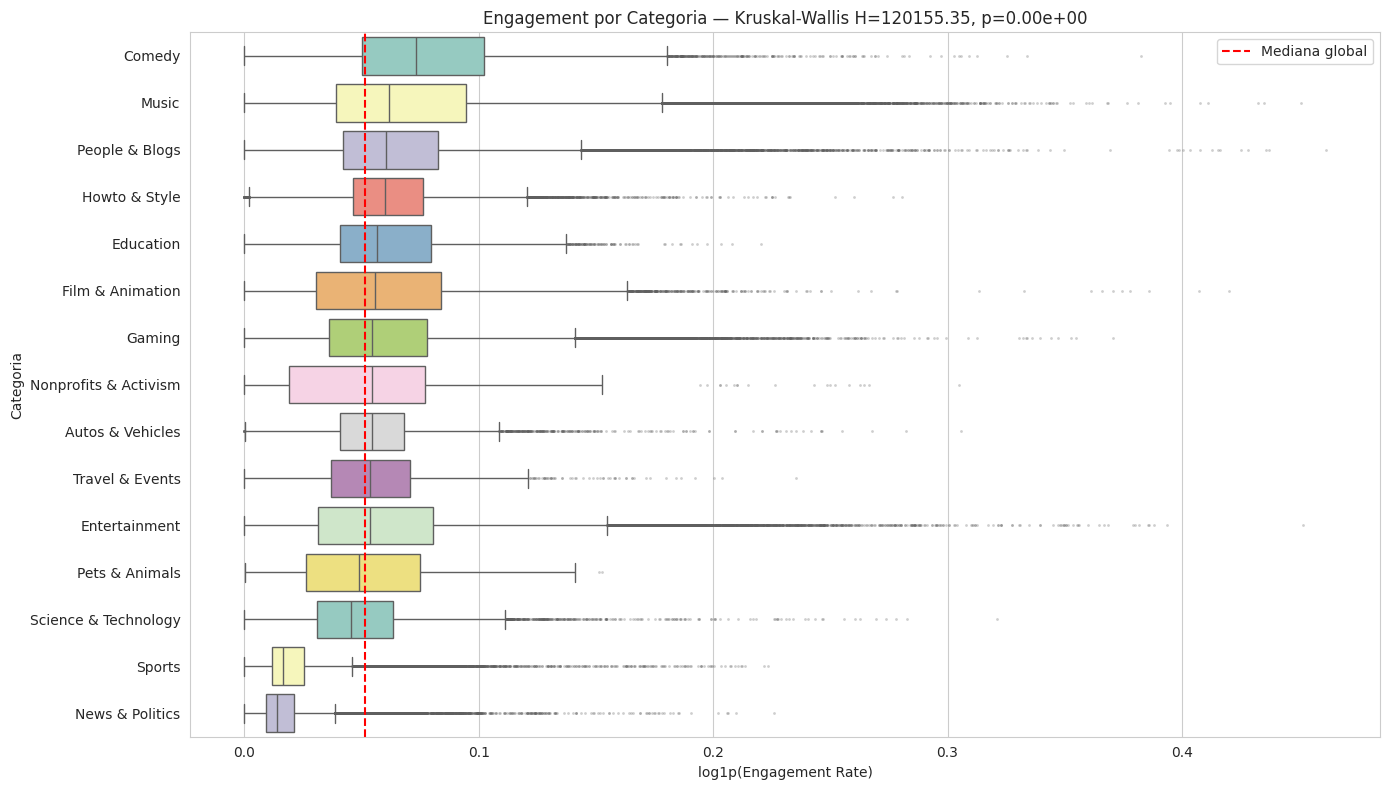

Figura guardada: fig_03_engagement_categoria.png


In [15]:
# Visualizacion: Boxplot por categoria
order_cat = (df_cat.groupby('category_name')['engagement_rate']
             .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_cat, y='category_name', x='log_engagement',
            order=order_cat, palette='Set3',
            flierprops=dict(marker='o', markersize=1, alpha=0.3),
            ax=ax)
ax.axvline(df['log_engagement'].median(), color='red',
           linestyle='--', lw=1.5, label='Mediana global')
ax.set_title(
    f'Engagement por Categoria — Kruskal-Wallis H={stat_kw_cat:.2f}, p={p_kw_cat:.2e}',
    fontsize=12
)
ax.set_xlabel('log1p(Engagement Rate)')
ax.set_ylabel('Categoria')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_03_engagement_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_03_engagement_categoria.png')

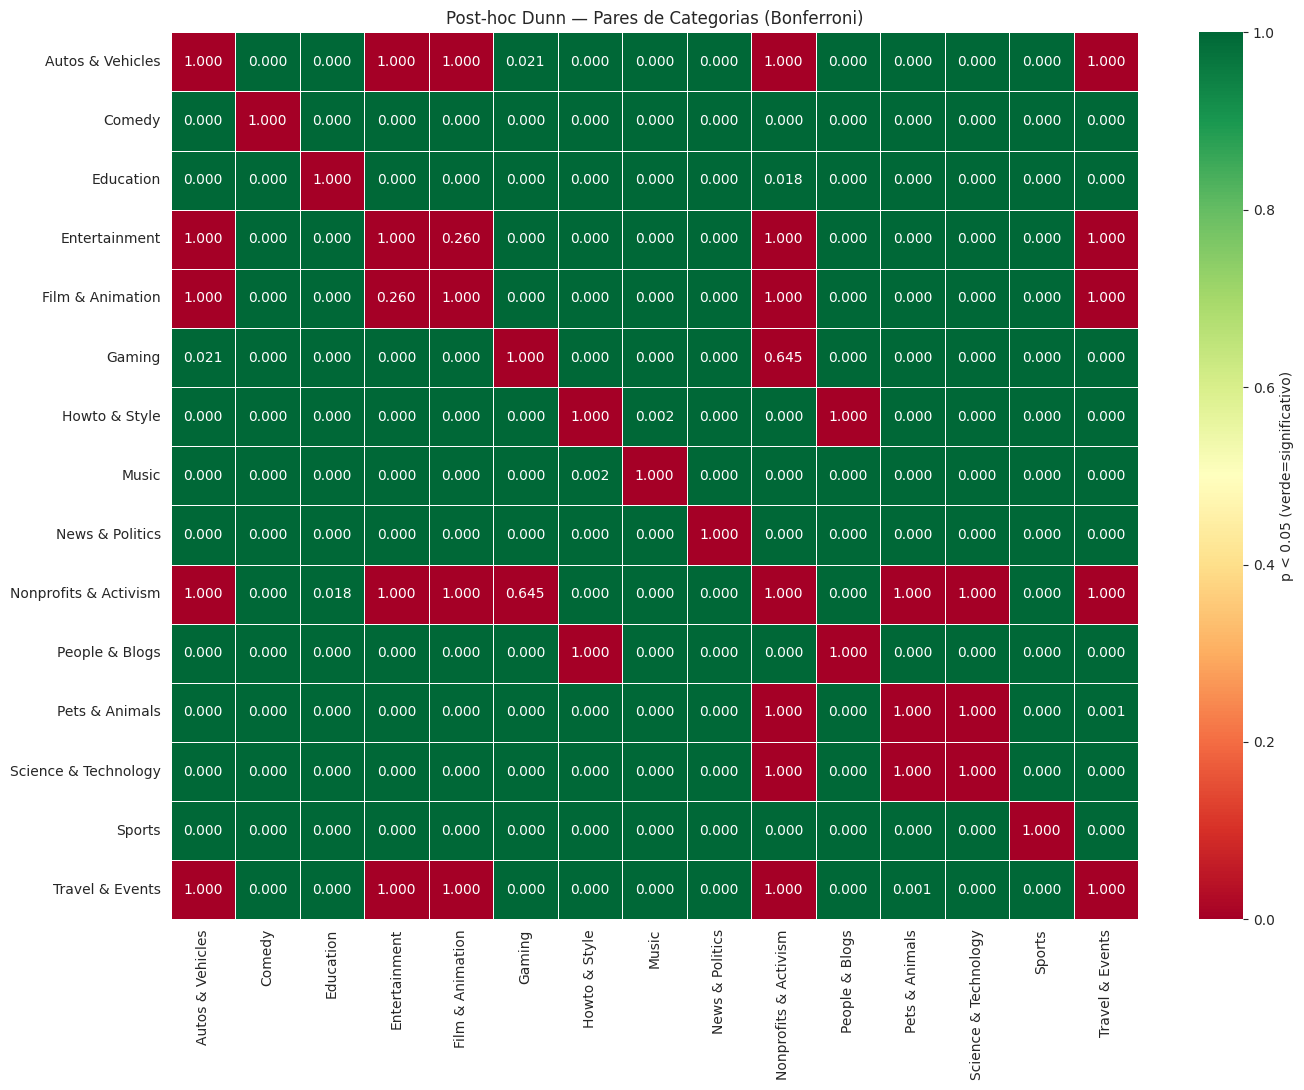

Figura guardada: fig_04_posthoc_dunn_categoria.png


In [16]:
# Heatmap post-hoc Dunn
fig, ax = plt.subplots(figsize=(14, 11))
sig_matrix = (dunn_result < ALPHA).astype(int)
sns.heatmap(sig_matrix, cmap='RdYlGn', linewidths=0.5,
            annot=dunn_result.round(3), fmt='.3f',
            cbar_kws={'label': 'p < 0.05 (verde=significativo)'},
            ax=ax)
ax.set_title('Post-hoc Dunn — Pares de Categorias (Bonferroni)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_04_posthoc_dunn_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_04_posthoc_dunn_categoria.png')

---
## SECCION 7 — Hipotesis 3: Diferencias por Franja Horaria de Publicacion

- **H0**: No existen diferencias significativas en el engagement entre franjas horarias
- **H1**: Al menos una franja horaria presenta engagement significativamente diferente
- **Prueba**: Kruskal-Wallis + Post-hoc Dunn


In [17]:
franjas = ['Madrugada (0-6h)', 'Manana (6-12h)', 'Tarde (12-18h)', 'Noche (18-24h)']
df_franja = df[df['franja_horaria'].isin(franjas)].copy()

grupos_franja2 = [g['engagement_rate'].dropna().values
                  for _, g in df_franja.groupby('franja_horaria')]

stat_kw_fr, p_kw_fr = kruskal(*grupos_franja2)

n_fr = sum(len(g) for g in grupos_franja2)
k_fr = len(grupos_franja2)
eta2_fr = (stat_kw_fr - k_fr + 1) / (n_fr - k_fr)

print('=' * 58)
print('  KRUSKAL-WALLIS — Engagement por Franja Horaria')
print('=' * 58)
print(f'  Franjas analizadas : {k_fr}')
print(f'  N total            : {n_fr:,}')
print(f'  Estadistico H      : {stat_kw_fr:.4f}')
print(f'  p-valor            : {p_kw_fr:.4e}')
print(f'  Eta-squared        : {eta2_fr:.4f}')
print('=' * 58)
if p_kw_fr < ALPHA:
    print(f'RESULTADO: Se RECHAZA H0 (p={p_kw_fr:.4e} < {ALPHA})')
    print('Existen diferencias significativas entre franjas horarias')
else:
    print(f'RESULTADO: No se rechaza H0 (p={p_kw_fr:.4e} >= {ALPHA})')

  KRUSKAL-WALLIS — Engagement por Franja Horaria
  Franjas analizadas : 4
  N total            : 528,663
  Estadistico H      : 6461.8821
  p-valor            : 0.0000e+00
  Eta-squared        : 0.0122
RESULTADO: Se RECHAZA H0 (p=0.0000e+00 < 0.05)
Existen diferencias significativas entre franjas horarias


In [18]:
# Estadisticas por franja
stats_franja = df_franja.groupby('franja_horaria')['engagement_rate'].agg(
    n='count', media='mean', mediana='median', std='std'
).round(4)
print('Estadisticas por Franja Horaria:')
display(stats_franja)

# Post-hoc Dunn franjas
dunn_franja = sp.posthoc_dunn(
    df_franja, val_col='engagement_rate',
    group_col='franja_horaria', p_adjust='bonferroni'
)
print('\nPost-hoc Dunn — p-valores entre franjas:')
display(dunn_franja.round(4))

Estadisticas por Franja Horaria:


,n,media,mediana,std
franja_horaria,,,,
Madrugada (0-6h),131754,0.0571,0.0473,0.0459
Manana (6-12h),29345,0.0563,0.0390,0.0535
Noche (18-24h),204784,0.0636,0.0574,0.0418
Tarde (12-18h),162780,0.0628,0.0536,0.0462



Post-hoc Dunn — p-valores entre franjas:


,Madrugada (0-6h),Manana (6-12h),Noche (18-24h),Tarde (12-18h)
Madrugada (0-6h),1.0000,0.0000,0.0000,0.0000
Manana (6-12h),0.0000,1.0000,0.0000,0.0000
Noche (18-24h),0.0000,0.0000,1.0000,0.0000
Tarde (12-18h),0.0000,0.0000,0.0000,1.0000


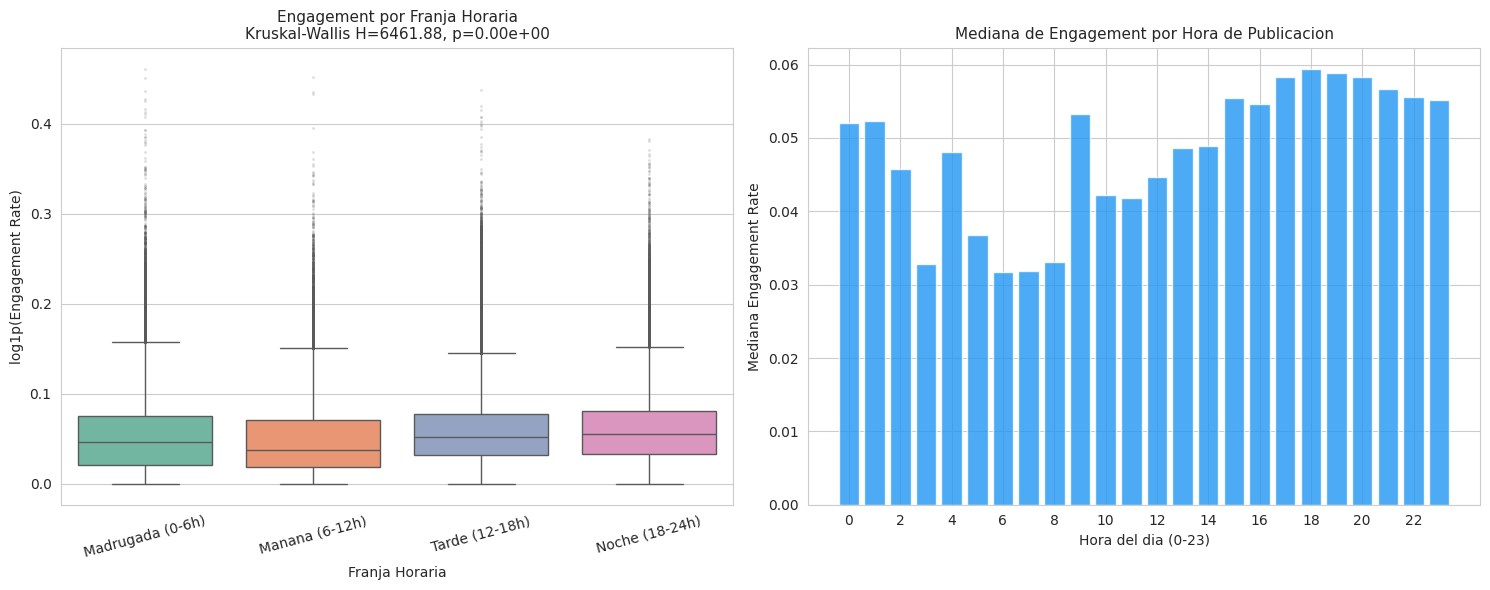

Figura guardada: fig_05_engagement_franja.png


In [19]:
# Visualizacion franja horaria
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(data=df_franja, x='franja_horaria', y='log_engagement',
            order=franjas, palette='Set2',
            flierprops=dict(marker='o', markersize=1, alpha=0.2),
            ax=axes[0])
axes[0].set_title(
    f'Engagement por Franja Horaria\nKruskal-Wallis H={stat_kw_fr:.2f}, p={p_kw_fr:.2e}',
    fontsize=11
)
axes[0].set_xlabel('Franja Horaria')
axes[0].set_ylabel('log1p(Engagement Rate)')
axes[0].tick_params(axis='x', rotation=15)

# Media de engagement por hora del dia
eng_hora = df.groupby('publish_hour')['engagement_rate'].median().reset_index()
axes[1].bar(eng_hora['publish_hour'], eng_hora['engagement_rate'],
            color='#2196F3', alpha=0.8, edgecolor='white')
axes[1].set_title('Mediana de Engagement por Hora de Publicacion', fontsize=11)
axes[1].set_xlabel('Hora del dia (0-23)')
axes[1].set_ylabel('Mediana Engagement Rate')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_05_engagement_franja.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_05_engagement_franja.png')

---
## SECCION 8 — Hipotesis 4: Diferencias por Dia de la Semana

- **H0**: No existen diferencias significativas en el engagement entre dias de la semana
- **H1**: Al menos un dia presenta engagement significativamente diferente
- **Prueba**: Kruskal-Wallis + Post-hoc Dunn


In [20]:
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
df_dias = df[df['publish_dayname'].isin(orden_dias)].copy()

grupos_dias = [g['engagement_rate'].dropna().values
               for _, g in df_dias.groupby('publish_dayname')]

stat_kw_dias, p_kw_dias = kruskal(*grupos_dias)

print('=' * 58)
print('  KRUSKAL-WALLIS — Engagement por Dia de la Semana')
print('=' * 58)
print(f'  Estadistico H : {stat_kw_dias:.4f}')
print(f'  p-valor       : {p_kw_dias:.4e}')
print('=' * 58)
if p_kw_dias < ALPHA:
    print(f'RESULTADO: Se RECHAZA H0 (p < {ALPHA})')
else:
    print(f'RESULTADO: No se rechaza H0 (p >= {ALPHA})')

  KRUSKAL-WALLIS — Engagement por Dia de la Semana
  Estadistico H : 3194.9467
  p-valor       : 0.0000e+00
RESULTADO: Se RECHAZA H0 (p < 0.05)


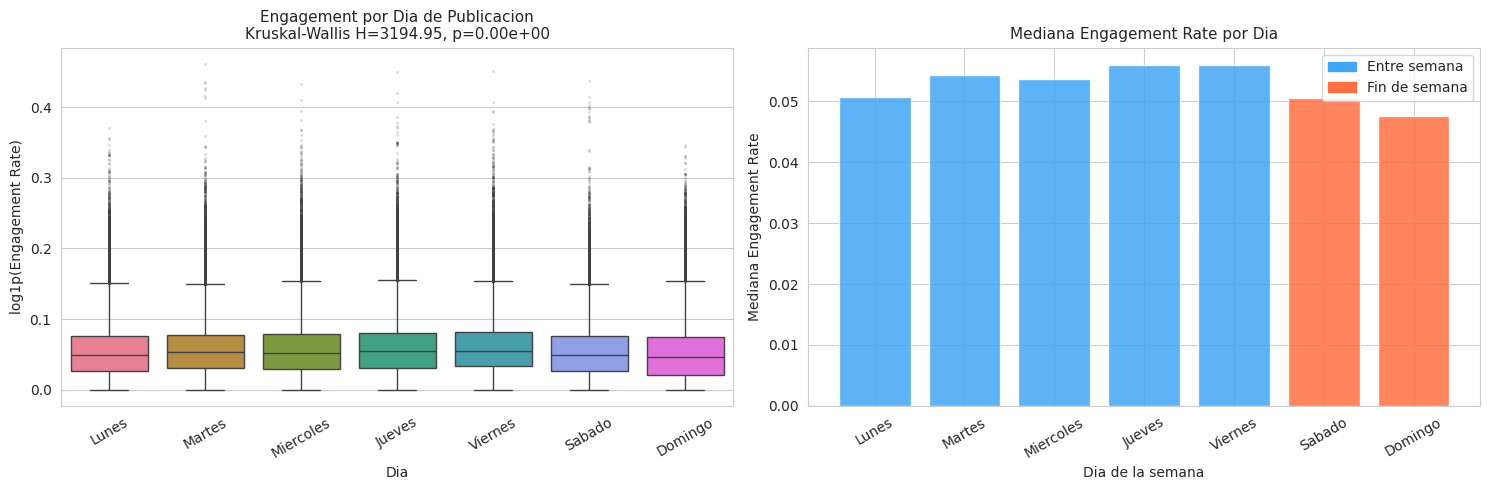

Figura guardada: fig_06_engagement_dia.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por dia
sns.boxplot(data=df_dias, x='publish_dayname', y='log_engagement',
            order=orden_dias, palette='husl',
            flierprops=dict(marker='o', markersize=1, alpha=0.2),
            ax=axes[0])
axes[0].set_title(
    f'Engagement por Dia de Publicacion\nKruskal-Wallis H={stat_kw_dias:.2f}, p={p_kw_dias:.2e}',
    fontsize=11
)
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('log1p(Engagement Rate)')
axes[0].tick_params(axis='x', rotation=30)

# Mediana por dia
med_dia = df_dias.groupby('publish_dayname')['engagement_rate'].median().reindex(orden_dias)
colores_dias = ['#FF7043' if d in ['Sabado','Domingo'] else '#42A5F5' for d in orden_dias]
axes[1].bar(orden_dias, med_dia.values, color=colores_dias, alpha=0.85, edgecolor='white')
axes[1].set_title('Mediana Engagement Rate por Dia', fontsize=11)
axes[1].set_xlabel('Dia de la semana')
axes[1].set_ylabel('Mediana Engagement Rate')
axes[1].tick_params(axis='x', rotation=30)
patch_sem = mpatches.Patch(color='#42A5F5', label='Entre semana')
patch_fin = mpatches.Patch(color='#FF7043', label='Fin de semana')
axes[1].legend(handles=[patch_sem, patch_fin])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_06_engagement_dia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_06_engagement_dia.png')

---
## SECCION 9 — Hipotesis 5: Diferencias por Numero de Tags

- **H0**: No existen diferencias significativas en el engagement segun el numero de tags
- **H1**: El numero de tags influye significativamente en el engagement
- **Prueba**: Kruskal-Wallis + Post-hoc Dunn
- **Adicional**: Correlacion de Spearman entre num_tags y engagement_rate


In [22]:
# Kruskal-Wallis por rango de tags
grupos_tags = [g['engagement_rate'].dropna().values
               for _, g in df.groupby('rango_tags', observed=True)]

stat_kw_tags, p_kw_tags = kruskal(*grupos_tags)

# Correlacion Spearman
corr_sp, p_sp = stats.spearmanr(
    df['num_tags'].dropna(),
    df.loc[df['num_tags'].notna(), 'engagement_rate']
)

print('=' * 58)
print('  KRUSKAL-WALLIS — Engagement por Rango de Tags')
print('=' * 58)
print(f'  Estadistico H : {stat_kw_tags:.4f}')
print(f'  p-valor       : {p_kw_tags:.4e}')
print('=' * 58)
print(f'\n  CORRELACION SPEARMAN — num_tags vs engagement_rate')
print(f'  rho   : {corr_sp:.4f}')
print(f'  p-val : {p_sp:.4e}')
if p_kw_tags < ALPHA:
    print(f'\nRESULTADO: Se RECHAZA H0 — el numero de tags SI influye en el engagement')
else:
    print(f'\nRESULTADO: No se rechaza H0')

  KRUSKAL-WALLIS — Engagement por Rango de Tags
  Estadistico H : 5206.8239
  p-valor       : 0.0000e+00

  CORRELACION SPEARMAN — num_tags vs engagement_rate
  rho   : -0.0724
  p-val : 0.0000e+00

RESULTADO: Se RECHAZA H0 — el numero de tags SI influye en el engagement


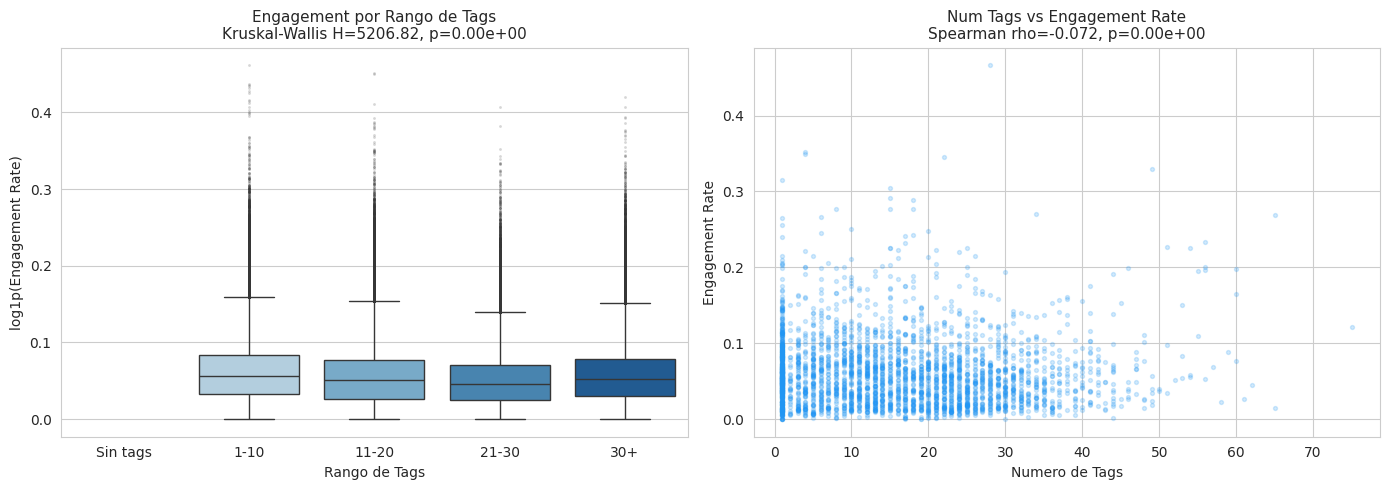

Figura guardada: fig_07_engagement_tags.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por rango de tags
orden_tags = ['Sin tags', '1-10', '11-20', '21-30', '30+']
sns.boxplot(data=df, x='rango_tags', y='log_engagement',
            order=orden_tags, palette='Blues',
            flierprops=dict(marker='o', markersize=1, alpha=0.2),
            ax=axes[0])
axes[0].set_title(
    f'Engagement por Rango de Tags\nKruskal-Wallis H={stat_kw_tags:.2f}, p={p_kw_tags:.2e}',
    fontsize=11
)
axes[0].set_xlabel('Rango de Tags')
axes[0].set_ylabel('log1p(Engagement Rate)')

# Scatter num_tags vs engagement (muestra)
muestra_tags = df[['num_tags', 'engagement_rate']].dropna().sample(3000, random_state=42)
axes[1].scatter(muestra_tags['num_tags'], muestra_tags['engagement_rate'],
                alpha=0.2, s=8, color='#2196F3')
axes[1].set_title(
    f'Num Tags vs Engagement Rate\nSpearman rho={corr_sp:.3f}, p={p_sp:.2e}',
    fontsize=11
)
axes[1].set_xlabel('Numero de Tags')
axes[1].set_ylabel('Engagement Rate')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_07_engagement_tags.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_07_engagement_tags.png')

---
## SECCION 10 — Hipotesis 6: Chi-cuadrado (Variables Categoricas)

### 10.1 — Categoria vs Comments Disabled
- **H0**: No existe asociacion entre la categoria y el estado de comentarios
- **H1**: Existe asociacion significativa entre categoria y estado de comentarios

### 10.2 — Categoria vs Ratings Disabled
- **H0**: No existe asociacion entre la categoria y el estado de valoraciones
- **H1**: Existe asociacion significativa

### 10.3 — Pais vs Engagement alto/bajo
- **H0**: No existe asociacion entre el pais y tener engagement alto
- **H1**: Existe asociacion entre pais y nivel de engagement


In [24]:
# ── 10.1 Categoria vs Comments Disabled ──
tabla_1 = pd.crosstab(df['category_name'], df['comments_disabled'])
chi2_1, p_1, dof_1, _ = chi2_contingency(tabla_1)
n_1 = tabla_1.sum().sum()
cramer_1 = np.sqrt(chi2_1 / (n_1 * (min(tabla_1.shape) - 1)))

# ── 10.2 Categoria vs Ratings Disabled ──
tabla_2 = pd.crosstab(df['category_name'], df['ratings_disabled'])
chi2_2, p_2, dof_2, _ = chi2_contingency(tabla_2)
n_2 = tabla_2.sum().sum()
cramer_2 = np.sqrt(chi2_2 / (n_2 * (min(tabla_2.shape) - 1)))

# ── 10.3 Pais vs Engagement alto ──
mediana_global = df['engagement_rate'].median()
df['engagement_alto'] = df['engagement_rate'] > mediana_global
tabla_3 = pd.crosstab(df['country'], df['engagement_alto'])
chi2_3, p_3, dof_3, _ = chi2_contingency(tabla_3)
n_3 = tabla_3.sum().sum()
cramer_3 = np.sqrt(chi2_3 / (n_3 * (min(tabla_3.shape) - 1)))

print('=' * 65)
print('  PRUEBAS CHI-CUADRADO')
print('=' * 65)
print(f'  Categoria vs Comments Disabled:')
print(f'    chi2={chi2_1:.2f}  gl={dof_1}  p={p_1:.4e}  V Cramer={cramer_1:.4f}')
print(f'    -> {"SIGNIFICATIVO" if p_1 < ALPHA else "No significativo"}')
print(f'\n  Categoria vs Ratings Disabled:')
print(f'    chi2={chi2_2:.2f}  gl={dof_2}  p={p_2:.4e}  V Cramer={cramer_2:.4f}')
print(f'    -> {"SIGNIFICATIVO" if p_2 < ALPHA else "No significativo"}')
print(f'\n  Pais vs Engagement Alto (> mediana):')
print(f'    chi2={chi2_3:.2f}  gl={dof_3}  p={p_3:.4e}  V Cramer={cramer_3:.4f}')
print(f'    -> {"SIGNIFICATIVO" if p_3 < ALPHA else "No significativo"}')
print('=' * 65)

  PRUEBAS CHI-CUADRADO
  Categoria vs Comments Disabled:
    chi2=10527.63  gl=14  p=0.0000e+00  V Cramer=0.1411
    -> SIGNIFICATIVO

  Categoria vs Ratings Disabled:
    chi2=589.29  gl=14  p=1.0127e-116  V Cramer=0.0334
    -> SIGNIFICATIVO

  Pais vs Engagement Alto (> mediana):
    chi2=3097.58  gl=1  p=0.0000e+00  V Cramer=0.0765
    -> SIGNIFICATIVO


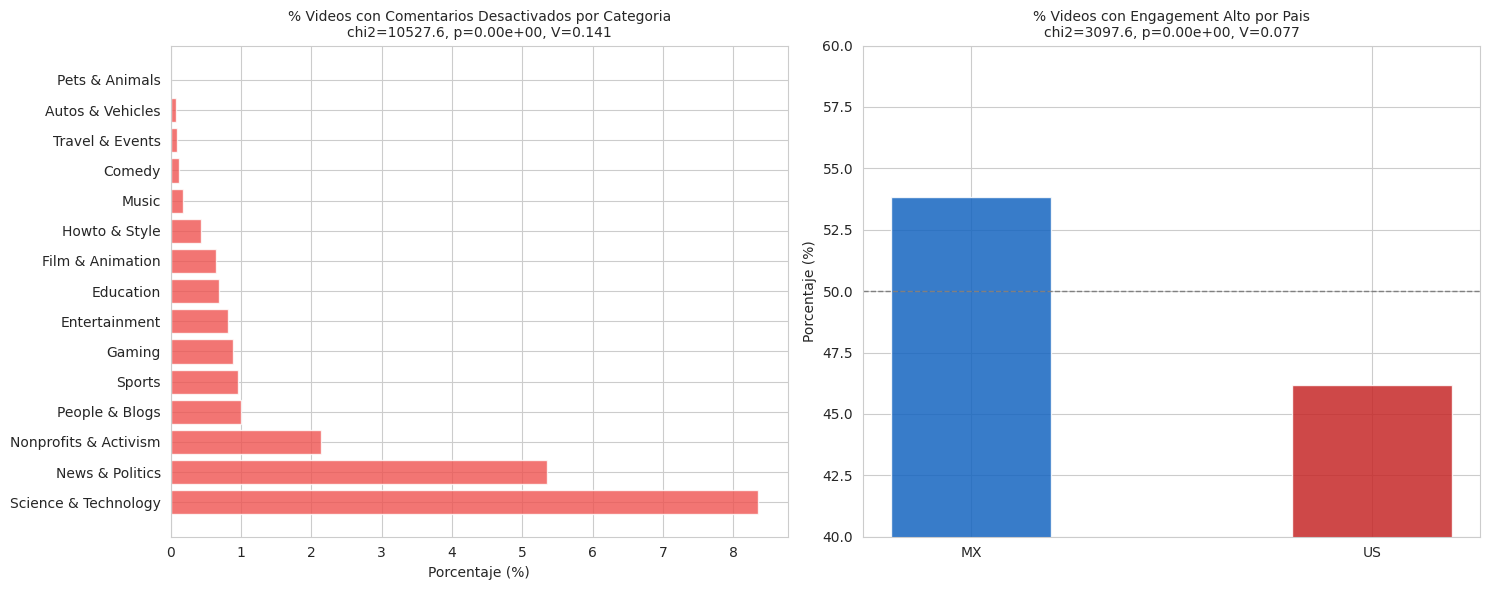

Figura guardada: fig_08_chi_cuadrado.png


In [25]:
# Visualizacion chi-cuadrado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Proporcion comments_disabled por categoria
prop_comments = df.groupby('category_name')['comments_disabled'].mean().sort_values(ascending=False)
axes[0].barh(prop_comments.index, prop_comments.values * 100,
             color='#EF5350', alpha=0.8, edgecolor='white')
axes[0].set_title(
    f'% Videos con Comentarios Desactivados por Categoria\nchi2={chi2_1:.1f}, p={p_1:.2e}, V={cramer_1:.3f}',
    fontsize=10
)
axes[0].set_xlabel('Porcentaje (%)')

# Proporcion engagement_alto por pais
prop_eng = df.groupby('country')['engagement_alto'].mean() * 100
axes[1].bar(prop_eng.index, prop_eng.values,
            color=['#1565C0', '#C62828'], alpha=0.85, edgecolor='white', width=0.4)
axes[1].axhline(50, color='gray', linestyle='--', lw=1)
axes[1].set_title(
    f'% Videos con Engagement Alto por Pais\nchi2={chi2_3:.1f}, p={p_3:.2e}, V={cramer_3:.3f}',
    fontsize=10
)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(40, 60)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_08_chi_cuadrado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_08_chi_cuadrado.png')

---
## SECCION 11 — Tabla Resumen de Resultados Inferenciales (formato tesis)


In [26]:
resumen = pd.DataFrame([
    {
        'Hipotesis': 'H1 - US vs MX',
        'Variable agrupacion': 'Pais',
        'Prueba': 'Mann-Whitney U',
        'Estadistico': f'U={stat_mw:.0f}',
        'p-valor': f'{p_mw:.4e}',
        'Effect size': f'r={r_effect:.4f}',
        'Decision': 'Rechazar H0' if p_mw < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H2 - Categoria',
        'Variable agrupacion': 'Categoria de contenido',
        'Prueba': 'Kruskal-Wallis',
        'Estadistico': f'H={stat_kw_cat:.2f}',
        'p-valor': f'{p_kw_cat:.4e}',
        'Effect size': f'eta2={eta2_cat:.4f}',
        'Decision': 'Rechazar H0' if p_kw_cat < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H3 - Franja Horaria',
        'Variable agrupacion': 'Franja horaria publicacion',
        'Prueba': 'Kruskal-Wallis',
        'Estadistico': f'H={stat_kw_fr:.2f}',
        'p-valor': f'{p_kw_fr:.4e}',
        'Effect size': f'eta2={eta2_fr:.4f}',
        'Decision': 'Rechazar H0' if p_kw_fr < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H4 - Dia semana',
        'Variable agrupacion': 'Dia de publicacion',
        'Prueba': 'Kruskal-Wallis',
        'Estadistico': f'H={stat_kw_dias:.2f}',
        'p-valor': f'{p_kw_dias:.4e}',
        'Effect size': '—',
        'Decision': 'Rechazar H0' if p_kw_dias < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H5 - Num Tags',
        'Variable agrupacion': 'Rango de tags',
        'Prueba': 'Kruskal-Wallis + Spearman',
        'Estadistico': f'H={stat_kw_tags:.2f} / rho={corr_sp:.3f}',
        'p-valor': f'{p_kw_tags:.4e}',
        'Effect size': f'rho={corr_sp:.4f}',
        'Decision': 'Rechazar H0' if p_kw_tags < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H6a - Cat x Comments',
        'Variable agrupacion': 'Categoria vs Comments Disabled',
        'Prueba': 'Chi-cuadrado',
        'Estadistico': f'chi2={chi2_1:.2f}',
        'p-valor': f'{p_1:.4e}',
        'Effect size': f'V={cramer_1:.4f}',
        'Decision': 'Rechazar H0' if p_1 < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H6b - Cat x Ratings',
        'Variable agrupacion': 'Categoria vs Ratings Disabled',
        'Prueba': 'Chi-cuadrado',
        'Estadistico': f'chi2={chi2_2:.2f}',
        'p-valor': f'{p_2:.4e}',
        'Effect size': f'V={cramer_2:.4f}',
        'Decision': 'Rechazar H0' if p_2 < ALPHA else 'No rechazar H0'
    },
    {
        'Hipotesis': 'H6c - Pais x Eng Alto',
        'Variable agrupacion': 'Pais vs Engagement alto',
        'Prueba': 'Chi-cuadrado',
        'Estadistico': f'chi2={chi2_3:.2f}',
        'p-valor': f'{p_3:.4e}',
        'Effect size': f'V={cramer_3:.4f}',
        'Decision': 'Rechazar H0' if p_3 < ALPHA else 'No rechazar H0'
    }
])

print('TABLA RESUMEN — PRUEBAS DE HIPOTESIS (Objetivo 2)')
print('Nivel de significancia: alpha = 0.05')
display(resumen)

# Guardar tabla
resumen.to_csv('/content/tabla_resumen_hipotesis.csv', index=False, encoding='utf-8-sig')
print('\nTabla guardada: tabla_resumen_hipotesis.csv')

TABLA RESUMEN — PRUEBAS DE HIPOTESIS (Objetivo 2)
Nivel de significancia: alpha = 0.05


,Hipotesis,Variable agrupacion,Prueba,Estadistico,p-valor,Effect size,Decision
0,H1 - US vs MX,Pais,Mann-Whitney U,U=31269255942,0.0000e+00,r=inf,Rechazar H0
1,H2 - Categoria,Categoria de contenido,Kruskal-Wallis,H=120155.35,0.0000e+00,eta2=0.2273,Rechazar H0
2,H3 - Franja Horaria,Franja horaria publicacion,Kruskal-Wallis,H=6461.88,0.0000e+00,eta2=0.0122,Rechazar H0
3,H4 - Dia semana,Dia de publicacion,Kruskal-Wallis,H=3194.95,0.0000e+00,—,Rechazar H0
4,H5 - Num Tags,Rango de tags,Kruskal-Wallis + Spearman,H=5206.82 / rho=-0.072,0.0000e+00,rho=-0.0724,Rechazar H0
5,H6a - Cat x Comments,Categoria vs Comments Disabled,Chi-cuadrado,chi2=10527.63,0.0000e+00,V=0.1411,Rechazar H0
6,H6b - Cat x Ratings,Categoria vs Ratings Disabled,Chi-cuadrado,chi2=589.29,1.0127e-116,V=0.0334,Rechazar H0
7,H6c - Pais x Eng Alto,Pais vs Engagement alto,Chi-cuadrado,chi2=3097.58,0.0000e+00,V=0.0765,Rechazar H0



Tabla guardada: tabla_resumen_hipotesis.csv


---
## SECCION 12 — Reporte Final y Guardado de Figuras

In [27]:
print('=' * 60)
print('  REPORTE FINAL — OBJETIVO 2')
print('  Pruebas de Hipotesis — YouTube US + MX')
print('=' * 60)
print(f'  Nivel de significancia : alpha = {ALPHA}')
print(f'  Total de hipotesis     : 8')
rechazadas = resumen[resumen['Decision'] == 'Rechazar H0'].shape[0]
print(f'  H0 rechazadas          : {rechazadas}')
print(f'  H0 no rechazadas       : {8 - rechazadas}')
print()
for _, row in resumen.iterrows():
    icono = 'RECHAZAR H0' if row['Decision'] == 'Rechazar H0' else 'No rechazar H0'
    print(f'  {row["Hipotesis"]:25s} -> {icono}')
print()
figuras = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]
print(f'  Figuras generadas: {len(figuras)}')
for f in sorted(figuras):
    print(f'    {f}')
print()
print('=' * 60)
print('  OBJETIVO 2 COMPLETADO')
print('  Proximo paso: Notebook 3 — Analisis Factorial (AFE)')
print('=' * 60)

  REPORTE FINAL — OBJETIVO 2
  Pruebas de Hipotesis — YouTube US + MX
  Nivel de significancia : alpha = 0.05
  Total de hipotesis     : 8
  H0 rechazadas          : 8
  H0 no rechazadas       : 0

  H1 - US vs MX             -> RECHAZAR H0
  H2 - Categoria            -> RECHAZAR H0
  H3 - Franja Horaria       -> RECHAZAR H0
  H4 - Dia semana           -> RECHAZAR H0
  H5 - Num Tags             -> RECHAZAR H0
  H6a - Cat x Comments      -> RECHAZAR H0
  H6b - Cat x Ratings       -> RECHAZAR H0
  H6c - Pais x Eng Alto     -> RECHAZAR H0

  Figuras generadas: 8
    fig_01_normalidad.png
    fig_02_us_vs_mx.png
    fig_03_engagement_categoria.png
    fig_04_posthoc_dunn_categoria.png
    fig_05_engagement_franja.png
    fig_06_engagement_dia.png
    fig_07_engagement_tags.png
    fig_08_chi_cuadrado.png

  OBJETIVO 2 COMPLETADO
  Proximo paso: Notebook 3 — Analisis Factorial (AFE)


In [29]:
# Guardar todo en Google Drive
from google.colab import drive
drive.mount('/content/drive')
import shutil, os
dest = '/content/drive/MyDrive/TFT_YouTube/figuras_obj2'
os.makedirs(dest, exist_ok=True)
for f in os.listdir(OUTPUT_DIR):
    shutil.copy(f'{OUTPUT_DIR}/{f}', f'{dest}/{f}')
shutil.copy('/content/tabla_resumen_hipotesis.csv',
            '/content/drive/MyDrive/TFT_YouTube/tabla_resumen_hipotesis.csv')
print('Todo guardado en Google Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Todo guardado en Google Drive
